# Behavioural mediation

Judge-annotated behaviour rates (self-correction, verification, strategy-shifting,
uncertainty-monitoring, problem-restatement, subgoal-decomposition) joined to IRT
difficulty and per-run directness. Produces the behavioural majority stripe and
supporting tables.

In [1]:
import os
from pathlib import Path

_root = Path.cwd()
while not (_root / 'pyproject.toml').exists() and _root.parent != _root:
    _root = _root.parent
os.chdir(_root)

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

mpl.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 9,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 8,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA = Path('data/processed')
OUT_FIGS = Path('figures')
OUT_FIGS.mkdir(parents=True, exist_ok=True)

DOMAIN_ORDER = ['code', 'math', 'sat']
DOMAIN_LABEL = {'code': 'Code', 'math': 'Math', 'sat': 'SAT'}
PAPER_LABEL = {
    'deepseek-r1-7b': 'DS-R1-7B', 'deepseek-r1-14b': 'DS-R1-14B',
    'deepseek-r1-32b': 'DS-R1-32B', 'qwq-32b': 'QwQ-32B',
    'r1-distill-llama-8b': 'R1-Llama-8B', 'phi-4-reasoning': 'Phi-4-R',
    'qwen-7b': 'Qwen-7B', 'qwen-14b': 'Qwen-14B', 'qwen-32b': 'Qwen-32B',
    'llama-8b': 'Llama-8B', 'phi-4': 'Phi-4',
}
REASONING_ORDER = ['deepseek-r1-7b', 'deepseek-r1-14b', 'deepseek-r1-32b',
                   'qwq-32b', 'r1-distill-llama-8b', 'phi-4-reasoning']
BASELINE_ORDER = ['qwen-7b', 'qwen-14b', 'qwen-32b', 'llama-8b', 'phi-4']
MODEL_ORDER = REASONING_ORDER + BASELINE_ORDER
PAPER_LABELS = [PAPER_LABEL[m] for m in MODEL_ORDER]


## Generate analysis inputs

Regenerates `data/processed/05_*.parquet` from per-model behavior_geometry
and llm_judge artefacts when `IRT_RESULTS_ROOT` is set. The prefix-directness
regeneration is gated behind `IRT_REGENERATE_HEAVY=1` because it reads
multi-GB `trajectory_traces.parquet` per model.


In [2]:
# >>> generation-marker <<<
RESULTS = Path(os.environ.get('IRT_RESULTS_ROOT', 'data/results'))
PROCESSED = Path('data/processed')
REGEN = RESULTS.exists() and any(RESULTS.rglob('behavior_geometry/token_cache.parquet'))
REGEN_HEAVY = REGEN and os.environ.get('IRT_REGENERATE_HEAVY', '0') == '1'
print(f'regenerate? {REGEN}   heavy? {REGEN_HEAVY}   (IRT_RESULTS_ROOT={RESULTS})')


regenerate? False   heavy? False   (IRT_RESULTS_ROOT=data/results)


### Behaviour atlas (per-model token caches)


In [3]:
# Concatenate per-model behavior_geometry token caches (6 reasoning models on code).
REASONING_MODELS = ['deepseek-r1-7b', 'deepseek-r1-14b', 'deepseek-r1-32b',
                   'r1-distill-llama-8b', 'qwq-32b', 'phi-4-reasoning']

if REGEN:
    frames = []
    for model in REASONING_MODELS:
        p = RESULTS / 'code' / model / 'behavior_geometry' / 'token_cache.parquet'
        if not p.exists():
            continue
        df = pd.read_parquet(p)
        df.insert(0, 'domain', 'code')
        df.insert(0, 'model_id', model)
        frames.append(df)
    if frames:
        out = pd.concat(frames, ignore_index=True)
        out.to_parquet(PROCESSED / '05_behavior_atlas.parquet', index=False)
        print(f'rebuilt 05_behavior_atlas.parquet ({len(out):,} rows, {out.model_id.nunique()} models)')
else:
    print('using shipped 05_behavior_atlas.parquet')


using shipped 05_behavior_atlas.parquet


### LLM judge aggregation (per-problem rates)


In [4]:
# Aggregate per-model llm_judge per-run rates to per-problem means.
ALL_11 = ['deepseek-r1-7b', 'deepseek-r1-14b', 'deepseek-r1-32b',
         'r1-distill-llama-8b', 'qwq-32b', 'phi-4-reasoning',
         'qwen-7b', 'qwen-14b', 'qwen-32b', 'llama-8b', 'phi-4']
JUDGES = ['gemma-2-9b-it', 'llama-3.1-8b-instruct', 'qwen2.5-7b-instruct']
BEHAVIOR_KEYS = ['self_correction', 'verification', 'strategy_shifting',
                'uncertainty_monitoring', 'problem_restatement', 'subgoal_decomposition']

if REGEN:
    cols_to_keep = ['problem_id']
    for b in BEHAVIOR_KEYS:
        for suf in ['_present', '_rate', '_count', '_pos_mean']:
            cols_to_keep.append(f'judge_{b}{suf}')
    frames = []
    for model in ALL_11:
        for dom in ['code', 'math']:
            for judge in JUDGES:
                p = RESULTS / dom / model / 'llm_judge' / judge / 'llm_judge.parquet'
                if not p.exists():
                    continue
                df = pd.read_parquet(p, columns=[c for c in cols_to_keep if c == 'problem_id' or 'judge_' in c])
                for b in BEHAVIOR_KEYS:
                    col = f'judge_{b}_present'
                    if col in df.columns:
                        df[col] = df[col].astype('float32')
                agg = df.groupby('problem_id', as_index=False).mean(numeric_only=True)
                agg.insert(0, 'judge', judge)
                agg.insert(0, 'domain', dom)
                agg.insert(0, 'model_id', model)
                frames.append(agg)
    if frames:
        out = pd.concat(frames, ignore_index=True)
        out.to_parquet(PROCESSED / '05_judge_aggregated.parquet', index=False)
        print(f'rebuilt 05_judge_aggregated.parquet ({len(out):,} rows, '
              f'{out.model_id.nunique()} models, {out.judge.nunique()} judges)')
else:
    print('using shipped 05_judge_aggregated.parquet')


using shipped 05_judge_aggregated.parquet


### Prefix directness (heavy step, opt-in)


In [5]:
# Per-run prefix-directness curves. Reads multi-GB trajectory_traces; gated on
# IRT_REGENERATE_HEAVY=1 to keep default Run All fast.
if REGEN_HEAVY:
    raise NotImplementedError(
        'Heavy prefix-directness regeneration is intentionally not inlined here. '
        'It requires re-running scripts/run_trajectory_analysis.py with prefix '
        'computation enabled, then concatenating the resulting per-model parquets. '
        'For pre-release reproduction, leave IRT_REGENERATE_HEAVY unset and use '
        'the shipped 05_prefix_directness.parquet.'
    )
else:
    print('using shipped 05_prefix_directness.parquet (set IRT_REGENERATE_HEAVY=1 to recompute)')


using shipped 05_prefix_directness.parquet (set IRT_REGENERATE_HEAVY=1 to recompute)


---


## Behavioural majority stripe (`behavioral_majority_stripe.pdf`)


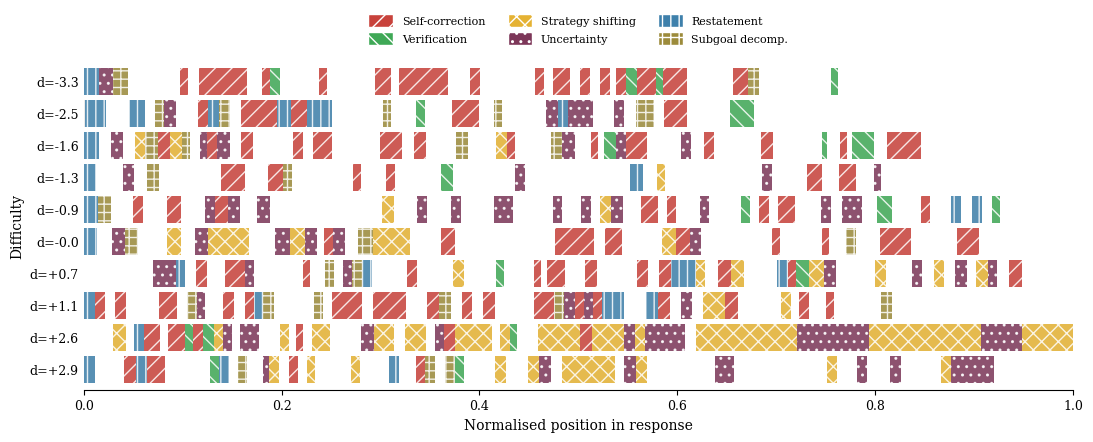

In [6]:
BEHAVIORS = [
    ('self_correction',      'Self-correction',    '#C8423B', '//'),
    ('verification',         'Verification',       '#3FA856', '\\\\'),
    ('strategy_shifting',    'Strategy shifting',  '#E5B233', 'xx'),
    ('uncertainty_monitoring','Uncertainty',       '#7D3759', '..'),
    ('problem_restatement',  'Restatement',        '#3E80AB', '||'),
    ('subgoal_decomposition','Subgoal decomp.',    '#9C8B3B', '++'),
]
BCOLOR = {k: c for k, _, c, _ in BEHAVIORS}
BHATCH = {k: h for k, _, _, h in BEHAVIORS}

df_atlas = pd.read_parquet(DATA / '05_behavior_atlas.parquet')
df_atlas = df_atlas[(df_atlas['model_id'] == 'deepseek-r1-7b') & (df_atlas['domain'] == 'code')].copy()

df_diff = pd.read_parquet(DATA / '01_difficulties.parquet')
code_diff = df_diff[df_diff['item_id'].str.startswith('code_')].copy()
code_diff['problem_id'] = code_diff['item_id'].str.slice(len('code_'))
diff_map = code_diff.set_index('problem_id')['difficulty']

df_atlas['difficulty'] = df_atlas['problem_id'].map(diff_map)
df_atlas = df_atlas.dropna(subset=['difficulty'])

# pick 10 representative (problem, run) traces along the difficulty range
problem_diff = df_atlas.groupby('problem_id')['difficulty'].first().sort_values()
quantiles = np.linspace(0.05, 0.95, 10)
reps = []
for q in quantiles:
    target = problem_diff.quantile(q)
    pid = (problem_diff - target).abs().idxmin()
    runs = df_atlas[df_atlas['problem_id'] == pid]['run_idx'].unique()
    if len(runs) == 0:
        continue
    reps.append((pid, int(runs[0]), float(problem_diff.loc[pid])))

fig, ax = plt.subplots(figsize=(11, 5.0))
stripe_h = 0.85
for row_idx, (pid, run_idx, diff) in enumerate(reps):
    sub = (df_atlas[(df_atlas['problem_id'] == pid) & (df_atlas['run_idx'] == run_idx)]
           .sort_values('char_start').reset_index(drop=True))
    if sub.empty:
        continue
    char_max = float(sub['char_end'].max())
    if char_max <= 0:
        continue
    # extend each labeled point to the next point's start, so each token's category
    # paints the sentence/segment it is sampled from.
    starts = sub['char_start'].astype(float).values
    next_starts = np.concatenate([starts[1:], [char_max]])
    y = len(reps) - 1 - row_idx
    # light grey background for the entire row (everything not painted = post-think tail)
    ax.add_patch(plt.Rectangle((0, y), 1.0, stripe_h, facecolor='0.92', edgecolor='none'))
    for s, e, cat in zip(starts, next_starts, sub['dominant_cat'].values):
        x0 = s / char_max
        x1 = e / char_max
        if cat in BCOLOR:
            ax.add_patch(plt.Rectangle((x0, y), x1 - x0, stripe_h,
                                       facecolor=BCOLOR[cat], hatch=BHATCH[cat],
                                       edgecolor='white', linewidth=0.0, alpha=0.85))
        else:
            ax.add_patch(plt.Rectangle((x0, y), x1 - x0, stripe_h,
                                       facecolor='white', edgecolor='none'))

ax.set_xlim(0, 1)
ax.set_ylim(-0.2, len(reps))
ax.set_yticks([len(reps) - 1 - i + stripe_h / 2 for i in range(len(reps))])
ax.set_yticklabels([f'd={diff:+.1f}' for _, _, diff in reps])
ax.tick_params(axis='y', length=0)
ax.set_xlabel('Normalised position in response')
ax.set_ylabel('Difficulty')

legend_handles = [Patch(facecolor=c, hatch=h, edgecolor='white', label=lbl)
                  for _, lbl, c, h in BEHAVIORS]
ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.18),
          ncol=3, frameon=False, handlelength=2.2, handleheight=1.4)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(True)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig(OUT_FIGS / 'behavioral_majority_stripe.pdf', bbox_inches='tight')
fig.savefig(OUT_FIGS / 'behavioral_majority_stripe.png', dpi=150, bbox_inches='tight')
plt.show()


## ρ(difficulty, behaviour rate) per (model, domain, judge)


In [7]:
from scipy.stats import spearmanr
REASONING = ['deepseek-r1-7b', 'deepseek-r1-14b', 'deepseek-r1-32b',
             'r1-distill-llama-8b', 'qwq-32b', 'phi-4-reasoning']
BEHAVIOR_KEYS = [k for k, _, _, _ in BEHAVIORS]

df_judge = pd.read_parquet(DATA / '05_judge_aggregated.parquet')
all_diff = pd.read_parquet(DATA / '01_difficulties.parquet').copy()
all_diff['domain'] = all_diff['item_id'].str.split('_', n=1).str[0]
all_diff['problem_id'] = all_diff['item_id'].str.split('_', n=1).str[1]
all_diff = all_diff[['domain', 'problem_id', 'difficulty']]
df = df_judge.merge(all_diff, on=['domain', 'problem_id'], how='inner')

rows = []
for (model, dom, judge), grp in df.groupby(['model_id', 'domain', 'judge']):
    for b in BEHAVIOR_KEYS:
        col = f'judge_{b}_rate'
        if col not in grp.columns:
            continue
        s = grp[[col, 'difficulty']].dropna()
        if len(s) < 30:
            continue
        rho, _ = spearmanr(s[col], s['difficulty'])
        rows.append({'model_id': model, 'domain': dom, 'judge': judge, 'behavior': b, 'rho': rho})
df_rho = pd.DataFrame(rows)
rsn = df_rho[df_rho['model_id'].isin(REASONING)].copy()
table = rsn.groupby(['model_id', 'behavior'])['rho'].mean().unstack('behavior').round(3)
print('Spearman ρ(difficulty, behaviour rate), averaged over (judge, domain):')
print(table.to_string())


Spearman ρ(difficulty, behaviour rate), averaged over (judge, domain):
behavior             problem_restatement  self_correction  strategy_shifting  subgoal_decomposition  uncertainty_monitoring  verification
model_id                                                                                                                                 
deepseek-r1-14b                   -0.230            0.308              0.443                  0.085                   0.443        -0.280
deepseek-r1-32b                   -0.220            0.356              0.479                  0.031                   0.494        -0.150
deepseek-r1-7b                    -0.116            0.372              0.515                  0.009                   0.534        -0.123
phi-4-reasoning                   -0.142            0.364              0.409                  0.125                   0.330         0.138
qwq-32b                           -0.110            0.304              0.349                  0.153  

## Indirect-effect proportions (simple OLS mediation)


In [8]:
df_pref = pd.read_parquet(DATA / '05_prefix_directness.parquet')
df_pref = df_pref.copy()
df_pref['directness_late'] = df_pref['d_frac_090']
directness_per_problem = (
    df_pref.groupby(['model', 'domain', 'problem_id'])['directness_late']
    .mean().reset_index().rename(columns={'model': 'model_id'})
)
merged = df.merge(directness_per_problem, on=['model_id', 'domain', 'problem_id'], how='inner')

def fit(y, X):
    X = np.column_stack([np.ones(len(X)), X])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return coef

rows = []
for (model, dom, judge), grp in merged.groupby(['model_id', 'domain', 'judge']):
    if model not in REASONING:
        continue
    for b in BEHAVIOR_KEYS:
        col = f'judge_{b}_rate'
        s = grp[[col, 'difficulty', 'directness_late']].dropna()
        if len(s) < 30:
            continue
        c_tot = fit(s['directness_late'].values, s['difficulty'].values[:, None])
        total = c_tot[1]
        a = fit(s[col].values, s['difficulty'].values[:, None])[1]
        c_full = fit(s['directness_late'].values, np.column_stack([s['difficulty'], s[col]]))
        b_eff = c_full[2]
        indirect = a * b_eff
        prop = indirect / total if abs(total) > 1e-9 else np.nan
        rows.append({'model': model, 'domain': dom, 'judge': judge, 'behavior': b,
                     'prop_mediated': prop})
df_med = pd.DataFrame(rows)
summary = df_med.groupby(['model', 'behavior'])['prop_mediated'].mean().unstack('behavior').round(3)
print('Mean proportion mediated (averaged over judges and domains):')
print(summary.to_string())


Mean proportion mediated (averaged over judges and domains):
behavior             problem_restatement  self_correction  strategy_shifting  subgoal_decomposition  uncertainty_monitoring  verification
model                                                                                                                                    
deepseek-r1-14b                    0.190            0.218              0.231                  0.007                   0.170         0.099
deepseek-r1-32b                    0.180            0.391              0.320                  0.062                   0.332         0.111
deepseek-r1-7b                     0.152            0.391              0.368                  0.073                   0.427         0.128
phi-4-reasoning                    0.205            0.259              0.177                  0.048                   0.208         0.157
qwq-32b                            0.055            0.209              0.220                  0.020            

## Temporal directness dynamics


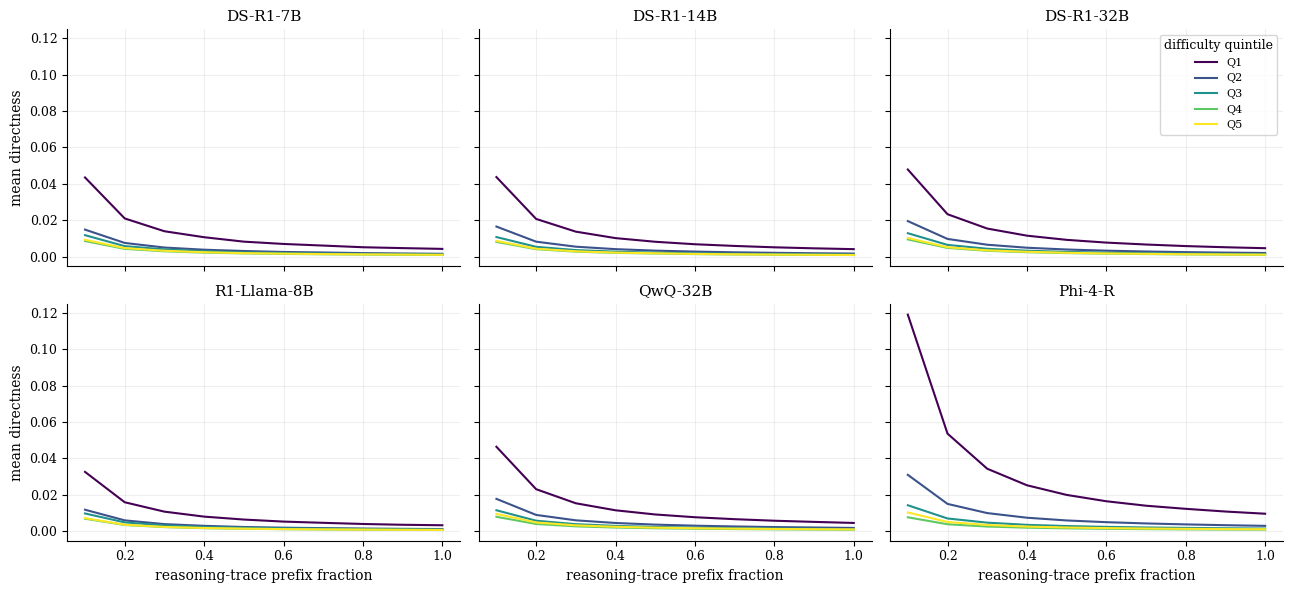

In [9]:
frac_cols = [c for c in df_pref.columns if c.startswith('d_frac_')]
fracs = [float(c.replace('d_frac_', '')) / 100 for c in frac_cols]
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharey=True, sharex=True)
for ax, model in zip(axes.flat, REASONING):
    sub = df_pref[(df_pref['model'] == model) & (df_pref['domain'] == 'code')].copy()
    if sub.empty:
        ax.set_title(f'{PAPER_LABEL[model]} (no data)'); continue
    sub['difficulty'] = sub['problem_id'].map(diff_map)
    sub = sub.dropna(subset=['difficulty'])
    sub['quintile'] = pd.qcut(sub['difficulty'], q=5, labels=False, duplicates='drop')
    for q in range(5):
        q_data = sub[sub['quintile'] == q]
        if q_data.empty:
            continue
        means = q_data[frac_cols].mean().values
        ax.plot(fracs, means, label=f'Q{q+1}', color=plt.cm.viridis(q / 4))
    ax.set_title(PAPER_LABEL[model])
    ax.grid(alpha=0.2)
for ax in axes[:, 0]:
    ax.set_ylabel('mean directness')
for ax in axes[-1]:
    ax.set_xlabel('reasoning-trace prefix fraction')
axes[0, -1].legend(fontsize=8, title='difficulty quintile')
fig.tight_layout()
fig.savefig(OUT_FIGS / 'temporal_directness_dynamics.pdf', bbox_inches='tight')
fig.savefig(OUT_FIGS / 'temporal_directness_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()
